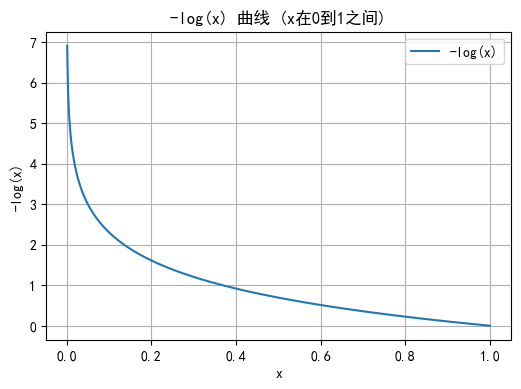

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 设置中文显示
rcParams['font.sans-serif'] = ['SimHei']   # 使用黑体
rcParams['axes.unicode_minus'] = False     # 正常显示负号

x = np.linspace(0.001, 1, 500)  # 避免log(0)导致无穷大，因此从0.001开始
y = -np.log(x)

plt.figure(figsize=(6,4))
plt.plot(x, y, label='-log(x)')
plt.xlabel('x')
plt.ylabel('-log(x)')
plt.title('-log(x) 曲线 (x在0到1之间)')
plt.grid(True)
plt.legend()
plt.show()

# fashion_minst分类实战

In [ ]:
import torch
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),#将PIL.Image变换成torch.Tensor，并且将像素值归一化到[0,1]
])

# 下载并加载训练数据集
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=False, transform=transform)

# 从训练集中分出5000样本作为验证集
train_size = len(full_train_dataset) - 5000
val_size = 5000
#random_split打乱样本
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)  # batch_size是一个批次样本的数量
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

# 下载并加载测试数据集
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [2]:
print("训练集样本数：", len(train_dataset))
print("验证集样本数：", len(val_dataset))
print("测试集样本数：", len(test_dataset))

训练集样本数： 55000
验证集样本数： 5000
测试集样本数： 10000


In [3]:
full_train_dataset.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [15]:
print(train_dataset[1])
28 * 28

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.2392, 0.7725, 0.6902, 0.7373, 0.7529, 0.7608,
          0.6510, 0.7647, 0.2000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.5961, 0.8784, 0.7529, 0.7804, 0.8157, 0.8118,
          0.7255, 0.9059, 0.4314, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.6471, 0.7922, 0.7529, 0.8078, 0.8118, 0.8314,
          0.7255, 0.8863, 0.4863, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.6784, 0.8353, 0.7569, 0.8275, 0.7451, 0.7843,
          0.7961, 0.8784, 0.5569, 0.0000, 0.0000, 0.0000

784

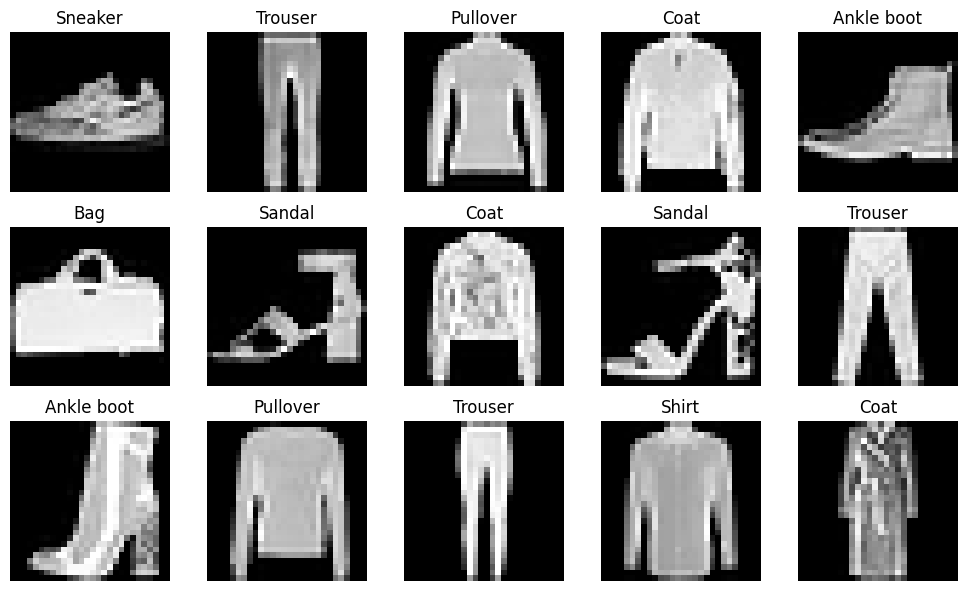

In [ ]:
import matplotlib.pyplot as plt

# FashionMNIST类别名称
class_names = full_train_dataset.classes

# 可视化train_dataset前15个样本，并显示类别名称
fig, axs = plt.subplots(3, 5, figsize=(10, 6))
axs = axs.flatten()

for i in range(15):
    # 这里train_dataset[i]会返回(img, label)两个值，
    # img是第i个样本的图像（已做Tensor变换），label是对应的类别标签。
    # 因为train_dataset由torch.utils.data.random_split分割自原始的Dataset，继承了其__getitem__方法，原始FashionMNIST的__getitem__返回图像和标签两个值。
    img, label = train_dataset[i]
    img = img.squeeze().numpy()  # 变成2D numpy数组  将(1,28,28)压缩成(28,28)
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(class_names[label])
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
len(train_dataset)

55000

In [16]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [16]:
train_dataset[0][1]

0

In [17]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
        
    def forward(self, x):
        print("Before view:", x.shape)
        x = x.view(x.size(0), -1)  # 展平成(batch_size, 784)
        print("After view:", x.shape)
        x = self.fc1(x)
        print("After fc1:", x.shape)
        x = self.relu1(x)
        print("After relu1:", x.shape)
        x = self.fc2(x)
        print("After fc2:", x.shape)
        x = self.relu2(x)
        print("After relu2:", x.shape)
        x = self.fc3(x)
        print("After fc3:", x.shape)
        return x
   

In [23]:
import torch

img, label = train_dataset[0]
img = img.unsqueeze(0)  # 增加batch维度，形状变为(1, 1, 28, 28) 或 (1, 28, 28)
model = NeuralNetwork()
output = model(img)
print("Logits:", output)
print("Predicted class:", torch.argmax(output, dim=1).item(), "True class:", label)

Before view: torch.Size([1, 28, 28])
After view: torch.Size([1, 784])
After fc1: torch.Size([1, 300])
After relu1: torch.Size([1, 300])
After fc2: torch.Size([1, 100])
After relu2: torch.Size([1, 100])
After fc3: torch.Size([1, 10])
Logits: tensor([[-0.1349, -0.1110,  0.0840, -0.0522,  0.0765, -0.0627, -0.0429, -0.0302,
          0.0561,  0.0455]], grad_fn=<AddmmBackward0>)
Predicted class: 2 True class: 0


In [ ]:
for images, labels in train_loader:
    print("images shape:", images.shape) #(bs,ch,h,w)
    print("labels shape:", labels.shape) #(bs)
    break  # 只输出第一个batch

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])


In [23]:
output = model(images)
print("Logits:", output.shape)

Before view: torch.Size([64, 1, 28, 28])
After view: torch.Size([64, 784])
After fc1: torch.Size([64, 300])
After relu1: torch.Size([64, 300])
After fc2: torch.Size([64, 100])
After relu2: torch.Size([64, 100])
After fc3: torch.Size([64, 10])
Logits: torch.Size([64, 10])


In [ ]:
#输出模型的参数，及总参数量
for name, param in model.named_parameters():
    print(f"Name: {name}, Shape: {param.shape}, Number of params: {param.numel()}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Name: fc1.weight, Shape: torch.Size([300, 784]), Number of params: 235200
Name: fc1.bias, Shape: torch.Size([300]), Number of params: 300
Name: fc2.weight, Shape: torch.Size([100, 300]), Number of params: 30000
Name: fc2.bias, Shape: torch.Size([100]), Number of params: 100
Name: fc3.weight, Shape: torch.Size([10, 100]), Number of params: 1000
Name: fc3.bias, Shape: torch.Size([10]), Number of params: 10
Total number of parameters: 266610


In [25]:
300*784

235200

In [26]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平成(batch_size, 784)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x
   
   

In [27]:
model = NeuralNetwork()

In [ ]:
import torch
import torch.optim as optim

# 判断设备：如果有GPU则用GPU，否则用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. 设置交叉熵损失函数和SGD优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 4. 编写评估函数 evaluating
def evaluating(model, dataloader, device=device):
    model.eval()  # 将模型设置为评估模式（不启用dropout/BN等）
    correct = 0   # 记录预测正确的样本数量
    total = 0     # 记录总的样本数量
    with torch.no_grad():  # 在评估时不计算梯度，节省显存，提高速度
        for images, labels in dataloader:  # 遍历dataloader中的所有batch
            images = images.to(device)     # 将输入数据移动到指定设备（CPU或GPU）
            labels = labels.to(device)     # 将标签移动到指定设备
            outputs = model(images)        # 前向传播，获得模型输出
            predicted = torch.argmax(outputs, dim=1)  # 获得最大logits的类别索引
            total += labels.size(0)        # 累加本batch中的样本数量
            correct += (predicted == labels).sum().item()  # 累加预测正确的数量
    acc = 100 * correct / total           # 计算准确率
    return acc                           # 返回准确率

# 5. 编写训练函数 train
def train(model, trainloader, valloader, criterion, optimizer, epochs=10, device=device):
    model.to(device)  # 将模型移动到指定设备
    for epoch in range(epochs):  # 循环训练若干个epoch
        model.train()  # 设置为训练模式
        running_loss = 0.0  # 记录累计损失
        for batch_idx, (images, labels) in enumerate(trainloader):  # 遍历训练集的每个batch
            images = images.to(device)  # 将图片数据移动到设备
            labels = labels.to(device)  # 将标签数据移动到设备
            
            optimizer.zero_grad()       # 梯度清零
            outputs = model(images)     # 前向传播
            loss = criterion(outputs, labels)  # 计算损失
            loss.backward()             # 反向传播
            optimizer.step()            # 更新参数,w=w-lr*grad
            
            running_loss += loss.item() # 累加本batch的损失
            if (batch_idx + 1) % 100 == 0:  # 每隔100个batch打印一次损失
                print(f'Epoch [{epoch + 1}/{epochs}], Step [{batch_idx + 1}/{len(trainloader)}], Loss: {loss.item():.4f}')

        avg_loss = running_loss / len(trainloader)  # 计算平均损失
        train_acc = evaluating(model, trainloader, device)  # 计算训练集准确率
        val_acc = evaluating(model, valloader, device)    # 计算测试集准确率
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, val Acc: {val_acc:.2f}%')
   

In [30]:
# 训练模型
num_epochs = 10  # 可以根据需要进行调节
train(model, train_loader, val_loader, criterion, optimizer, epochs=num_epochs, device=device)

Epoch [1/10], Step [100/860], Loss: 1.1504
Epoch [1/10], Step [200/860], Loss: 0.7217
Epoch [1/10], Step [300/860], Loss: 0.4009
Epoch [1/10], Step [400/860], Loss: 0.5774
Epoch [1/10], Step [500/860], Loss: 0.5225
Epoch [1/10], Step [600/860], Loss: 0.5209
Epoch [1/10], Step [700/860], Loss: 0.6081
Epoch [1/10], Step [800/860], Loss: 0.5197
Epoch [1/10], Loss: 0.7029, Train Acc: 83.97%, Test Acc: 83.26%
Epoch [2/10], Step [100/860], Loss: 0.3228
Epoch [2/10], Step [200/860], Loss: 0.6639
Epoch [2/10], Step [300/860], Loss: 0.5040
Epoch [2/10], Step [400/860], Loss: 0.4098
Epoch [2/10], Step [500/860], Loss: 0.3578
Epoch [2/10], Step [600/860], Loss: 0.6691
Epoch [2/10], Step [700/860], Loss: 0.4193
Epoch [2/10], Step [800/860], Loss: 0.4145
Epoch [2/10], Loss: 0.4360, Train Acc: 85.37%, Test Acc: 84.24%
Epoch [3/10], Step [100/860], Loss: 0.4645
Epoch [3/10], Step [200/860], Loss: 0.5243
Epoch [3/10], Step [300/860], Loss: 0.3143
Epoch [3/10], Step [400/860], Loss: 0.4449
Epoch [3/10]

In [28]:
55000/64

859.375